# Lab 7: Regularization in Logistic Regression

## Step 1: Data Loading and Cleaning
We will load the dataset and perform basic cleaning (handling missing values, encoding, and scaling if necessary).

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Load the dataset
df = pd.read_csv('/content/tourism_resource_dataset.csv')

# 1. Display first few rows
print("Initial Data:")
display(df.head())

# 2. Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# 3. Basic Cleaning Step: Drop rows with missing values (if any)
df_cleaned = df.dropna()

# 4. Encoding categorical variables (e.g., the target variable if it's text)
# Assuming the last column is the target for binary classification
target_col = df_cleaned.columns[-1]
le = LabelEncoder()
df_cleaned[target_col] = le.fit_transform(df_cleaned[target_col])

# Show cleaned summary
print("\nCleaned Data Info:")
display(df_cleaned.info())
print(f"Target classes: {le.classes_}")

Initial Data:


,timestamp,location_id,visitor_count,resource_usage_rate,temperature,air_quality_index,noise_level,season,peak_hour_flag,visitor_satisfaction,sensor_noise_flag,resource_prediction,resource_allocation,t_sne_dim1,t_sne_dim2
0,2024-12-01 00:00:00,LOC_003,808,0.907638,19.368864,127,51.506727,summer,0,5.502615,1,0.857819,high,-4.576337,0.582736
1,2024-12-01 01:00:00,LOC_001,948,0.974266,17.404945,37,55.901717,autumn,0,4.736401,0,0.961133,high,-28.314085,20.022820
2,2024-12-01 02:00:00,LOC_003,292,0.321912,16.366819,113,68.533024,winter,1,2.522827,0,0.306956,low,1.329948,5.881103
3,2024-12-01 03:00:00,LOC_003,592,0.811889,20.266316,52,85.301039,autumn,1,2.687745,1,0.701945,medium,-11.921675,20.376535
4,2024-12-01 04:00:00,LOC_001,89,0.936667,15.922471,145,52.258779,summer,1,1.094965,1,0.512834,medium,-6.068825,-4.793058



Missing values per column:
timestamp               0
location_id             0
visitor_count           0
resource_usage_rate     0
temperature             0
air_quality_index       0
noise_level             0
season                  0
peak_hour_flag          0
visitor_satisfaction    0
sensor_noise_flag       0
resource_prediction     0
resource_allocation     0
t_sne_dim1              0
t_sne_dim2              0
dtype: int64

Cleaned Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             1000 non-null   object 
 1   location_id           1000 non-null   object 
 2   visitor_count         1000 non-null   int64  
 3   resource_usage_rate   1000 non-null   float64
 4   temperature           1000 non-null   float64
 5   air_quality_index     1000 non-null   int64  
 6   noise_level           1000 non

None

Target classes: [-3.89148200e+01 -3.86471200e+01 -3.78260770e+01 -3.77925380e+01
 -3.71347100e+01 -3.70912550e+01 -3.64663100e+01 -3.58333930e+01
 -3.54700500e+01 -3.32427600e+01 -3.30605700e+01 -3.27519200e+01
 -3.20325850e+01 -3.17821750e+01 -3.16181140e+01 -3.13610040e+01
 -3.11704140e+01 -3.11005600e+01 -3.09061570e+01 -3.07073210e+01
 -3.05313110e+01 -3.04457530e+01 -2.98108860e+01 -2.97631150e+01
 -2.95740100e+01 -2.95123020e+01 -2.93872800e+01 -2.93530460e+01
 -2.92109200e+01 -2.91981980e+01 -2.86060030e+01 -2.85969770e+01
 -2.85376550e+01 -2.84188000e+01 -2.80909610e+01 -2.80135150e+01
 -2.78467700e+01 -2.77895050e+01 -2.77842120e+01 -2.73267690e+01
 -2.68991320e+01 -2.68367820e+01 -2.68186570e+01 -2.67711580e+01
 -2.67650870e+01 -2.65376700e+01 -2.64854680e+01 -2.64767880e+01
 -2.63322430e+01 -2.63034670e+01 -2.63032510e+01 -2.62088720e+01
 -2.61136760e+01 -2.58549180e+01 -2.58503100e+01 -2.55394210e+01
 -2.55072420e+01 -2.53991360e+01 -2.50756600e+01 -2.49827040e+01
 -2.49600

## Step 2: Define Input (X) and Output (y)
We will separate the features from the target label.

In [6]:
X = df_cleaned.drop(columns=['resource_allocation'])
y = df_cleaned['resource_allocation']

# Encode categorical features in X
for col in X.select_dtypes(include=['object']).columns:
    X[col] = LabelEncoder().fit_transform(X[col])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled and target defined.")

Features scaled and target defined.


## Step 3, 4 & 5: Data Splitting
Splitting the data into 80-20 ratio, then further using 70% of total for training and 30% of total for testing as per specific lab requirements.

In [3]:
# Lab specifies 70% train and 30% test split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 700
Testing set size: 300


## Step 6: Regularization Experiments
We will iterate through $\lambda$ values (where $C = 1/\lambda$) for both L1 (Lasso) and L2 (Ridge) regularization.

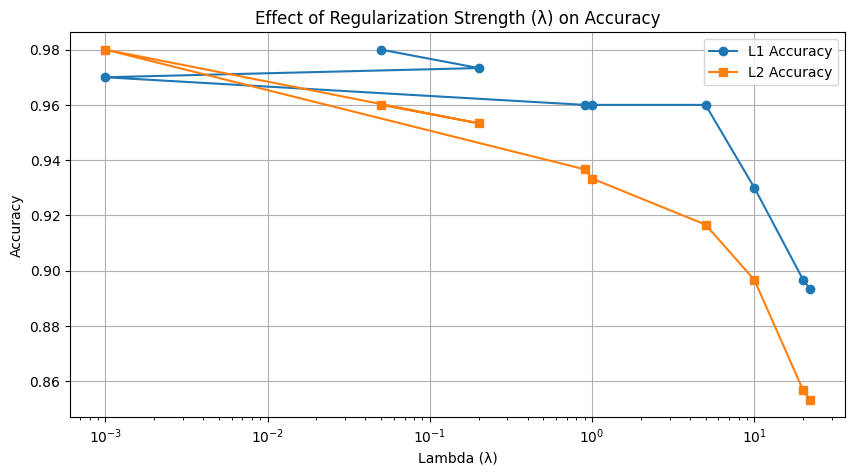

In [7]:
lambdas = [0.05, 0.2, 0.001, 0.9, 1, 5, 10, 20, 22]
l1_accuracies = []
l2_accuracies = []

# Re-split data to ensure consistency with updated y
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.30, random_state=42)

for l in lambdas:
    c_val = 1.0 / l

    # L1 Regularization
    model_l1 = LogisticRegression(penalty='l1', C=c_val, solver='liblinear', max_iter=5000)
    model_l1.fit(X_train, y_train)
    l1_accuracies.append(accuracy_score(y_test, model_l1.predict(X_test)))

    # L2 Regularization
    model_l2 = LogisticRegression(penalty='l2', C=c_val, solver='liblinear', max_iter=5000)
    model_l2.fit(X_train, y_train)
    l2_accuracies.append(accuracy_score(y_test, model_l2.predict(X_test)))

# Plotting results
plt.figure(figsize=(10, 5))
plt.plot(lambdas, l1_accuracies, label='L1 Accuracy', marker='o')
plt.plot(lambdas, l2_accuracies, label='L2 Accuracy', marker='s')
plt.xscale('log')
plt.xlabel('Lambda (λ)')
plt.ylabel('Accuracy')
plt.title('Effect of Regularization Strength (λ) on Accuracy')
plt.legend()
plt.grid(True)
plt.show()